In [ ]:
!pip install -q earthengine-api geemap rasterio numpy pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.5 MB/s eta 0:00:00


In [ ]:
import os
import glob
import shutil
import zipfile
import math

import ee
import geemap
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
ee.Authenticate()

In [ ]:
study_area = ee.Geometry.Rectangle([
    78.20, 17.25,
    78.65, 17.60
])

print("Study area defined.")

Study area defined.


In [ ]:
def mask_s2_clouds(image):

    qa = image.select("QA60")

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(
            qa.bitwiseAnd(cirrus_bit_mask).eq(0)
        )
    )

    return (
        image
        .updateMask(mask)
        .divide(10000)
        .copyProperties(image, ["system:time_start"])
    )

In [ ]:
def create_sentinel_composite(start_date, end_date):

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(study_area)
        .filterDate(start_date, end_date)
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                20
            )
        )
        .map(mask_s2_clouds)
    )

    print(
        "Images available:",
        collection.size().getInfo()
    )

    composite = (
        collection
        .median()
        .clip(study_area)
    )

    return composite

In [ ]:
image_2020 = create_sentinel_composite(
    "2020-01-01",
    "2020-02-01"
)

print("2020 composite created.")

Images available: 8
2020 composite created.


In [ ]:
image_2025 = create_sentinel_composite(
    "2025-01-01",
    "2025-02-01"
)

print("2025 composite created.")

Images available: 7
2025 composite created.


In [ ]:
def add_spectral_indices(image):

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")

    ndwi = image.normalizedDifference(
        ["B3", "B8"]
    ).rename("NDWI")

    ndbi = image.normalizedDifference(
        ["B11", "B8"]
    ).rename("NDBI")

    return image.addBands([
        ndvi,
        ndwi,
        ndbi
    ])

In [ ]:
features_2020 = add_spectral_indices(image_2020)
features_2025 = add_spectral_indices(image_2025)

print("Spectral indices added.")

Spectral indices added.


In [ ]:
feature_bands = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI"
]

print("Number of features:", len(feature_bands))
print(feature_bands)

Number of features: 9
['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']


In [ ]:
stack_2020 = features_2020.select(feature_bands)
stack_2025 = features_2025.select(feature_bands)

print("2020 and 2025 feature stacks created.")

2020 and 2025 feature stacks created.


In [ ]:
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 0.3
}

Map = geemap.Map()

Map.centerObject(study_area, 10)

Map.addLayer(
    stack_2020,
    rgb_vis,
    "Sentinel-2 2020"
)

Map.addLayer(
    stack_2025,
    rgb_vis,
    "Sentinel-2 2025"
)

Map

Map(center=[17.425070303037895, 78.42499999999899], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
xmin = 78.20
ymin = 17.25
xmax = 78.65
ymax = 17.60

tile_size = 0.05

print("Tile size:", tile_size)

Tile size: 0.05


In [ ]:
dataset_dir = "/content/lulc_dataset"

os.makedirs(dataset_dir, exist_ok=True)

os.makedirs(
    os.path.join(dataset_dir, "2020"),
    exist_ok=True
)

os.makedirs(
    os.path.join(dataset_dir, "2025"),
    exist_ok=True
)

os.makedirs(
    os.path.join(dataset_dir, "metadata"),
    exist_ok=True
)

print("Dataset directories created.")

Dataset directories created.


In [ ]:
download_dir_2020 = os.path.join(
    dataset_dir,
    "2020"
)

tile_number = 0

x = xmin

while x < xmax:

    x2 = min(x + tile_size, xmax)

    y = ymin

    while y < ymax:

        y2 = min(y + tile_size, ymax)

        tile_geometry = ee.Geometry.Rectangle([
            x,
            y,
            x2,
            y2
        ])

        tile = stack_2020.clip(
            tile_geometry
        )

        output_path = os.path.join(
            download_dir_2020,
            f"tile_{tile_number:03d}.tif"
        )

        print(
            f"Downloading 2020 tile {tile_number}: "
            f"{x:.2f},{y:.2f} → {x2:.2f},{y2:.2f}"
        )

        try:

            geemap.ee_export_image(
                tile,
                filename=output_path,
                scale=10,
                region=tile_geometry,
                file_per_band=False
            )

            if os.path.exists(output_path):

                size_mb = (
                    os.path.getsize(output_path)
                    / (1024 ** 2)
                )

                print(
                    f"✓ Saved: {size_mb:.2f} MB"
                )

            else:

                print("✗ Download failed.")

        except Exception as e:

            print(
                f"✗ Error: {e}"
            )

        tile_number += 1
        y += tile_size

    x += tile_size

print()
print("2020 tile download completed.")
print("Tiles attempted:", tile_number)

Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_000.tif
✓ Saved: 7.73 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_001.tif
✓ Saved: 7.67 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_002.tif
✓ Saved: 7.73 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_003.tif
✓ Saved: 7.77 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_004.tif
✓ Saved: 7.76 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_005.tif
✓ Saved: 7.71 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_006.tif
✓ Saved: 7.72 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_007.tif
✓ Saved: 7.59 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2020/tile_008.tif
✓ Saved: 7.74 MB
G

In [ ]:
download_dir_2025 = os.path.join(
    dataset_dir,
    "2025"
)

tile_number = 0

x = xmin

while x < xmax:

    x2 = min(x + tile_size, xmax)

    y = ymin

    while y < ymax:

        y2 = min(y + tile_size, ymax)

        tile_geometry = ee.Geometry.Rectangle([
            x,
            y,
            x2,
            y2
        ])

        tile = stack_2025.clip(
            tile_geometry
        )

        output_path = os.path.join(
            download_dir_2025,
            f"tile_{tile_number:03d}.tif"
        )

        print(
            f"Downloading 2025 tile {tile_number}: "
            f"{x:.2f},{y:.2f} → {x2:.2f},{y2:.2f}"
        )

        try:

            geemap.ee_export_image(
                tile,
                filename=output_path,
                scale=10,
                region=tile_geometry,
                file_per_band=False
            )

            if os.path.exists(output_path):

                size_mb = (
                    os.path.getsize(output_path)
                    / (1024 ** 2)
                )

                print(
                    f"✓ Saved: {size_mb:.2f} MB"
                )

            else:

                print("✗ Download failed.")

        except Exception as e:

            print(
                f"✗ Error: {e}"
            )

        tile_number += 1
        y += tile_size

    x += tile_size

print()
print("2025 tile download completed.")
print("Tiles attempted:", tile_number)

Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_000.tif
✓ Saved: 7.42 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_001.tif
✓ Saved: 7.31 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_002.tif
✓ Saved: 7.33 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_003.tif
✓ Saved: 7.34 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_004.tif
✓ Saved: 7.37 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_005.tif
✓ Saved: 7.31 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_006.tif
✓ Saved: 7.29 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_007.tif
✓ Saved: 7.33 MB
Generating URL ...
Please wait ...
Data downloaded to /content/lulc_dataset/2025/tile_008.tif
✓ Saved: 7.36 MB
G

In [ ]:
tiles_2020 = sorted(
    glob.glob(
        os.path.join(
            dataset_dir,
            "2020",
            "*.tif"
        )
    )
)

tiles_2025 = sorted(
    glob.glob(
        os.path.join(
            dataset_dir,
            "2025",
            "*.tif"
        )
    )
)

print("2020 tiles:", len(tiles_2020))
print("2025 tiles:", len(tiles_2025))

2020 tiles: 70
2025 tiles: 70


In [ ]:
def inspect_tiles(tile_files):

    results = []

    for file in tile_files:

        with rasterio.open(file) as src:

            results.append({
                "filename": os.path.basename(file),
                "size_MB": os.path.getsize(file) / (1024 ** 2),
                "width": src.width,
                "height": src.height,
                "bands": src.count,
                "dtype": str(src.dtypes[0])
            })

    return pd.DataFrame(results)

In [ ]:
info_2020 = inspect_tiles(tiles_2020)
info_2025 = inspect_tiles(tiles_2025)

print("2020")
display(info_2020)

print("2025")
display(info_2025)

2020


,filename,size_MB,width,height,bands,dtype
0,tile_000.tif,7.734612,558,557,9,float32
1,tile_001.tif,7.673804,558,558,9,float32
2,tile_002.tif,7.731650,558,557,9,float32
3,tile_003.tif,7.766566,558,558,9,float32
4,tile_004.tif,7.758879,558,558,9,float32
...,...,...,...,...,...,...
65,tile_065.tif,0.020142,1,557,9,float32
66,tile_066.tif,0.020873,1,558,9,float32
67,tile_067.tif,0.020288,1,558,9,float32
68,tile_068.tif,0.019622,1,557,9,float32


2025


,filename,size_MB,width,height,bands,dtype
0,tile_000.tif,7.420509,558,557,9,float32
1,tile_001.tif,7.313762,558,558,9,float32
2,tile_002.tif,7.331320,558,557,9,float32
3,tile_003.tif,7.341500,558,558,9,float32
4,tile_004.tif,7.370701,558,558,9,float32
...,...,...,...,...,...,...
65,tile_065.tif,0.019984,1,557,9,float32
66,tile_066.tif,0.020707,1,558,9,float32
67,tile_067.tif,0.020145,1,558,9,float32
68,tile_068.tif,0.019527,1,557,9,float32


In [ ]:
print("Tiny 2020 tiles:")
display(
    info_2020[
        info_2020["size_MB"] < 1
    ]
)

print("Tiny 2025 tiles:")
display(
    info_2025[
        info_2025["size_MB"] < 1
    ]
)

Tiny 2020 tiles:


,filename,size_MB,width,height,bands,dtype
63,tile_063.tif,0.020561,1,557,9,float32
64,tile_064.tif,0.019766,1,558,9,float32
65,tile_065.tif,0.020142,1,557,9,float32
66,tile_066.tif,0.020873,1,558,9,float32
67,tile_067.tif,0.020288,1,558,9,float32
68,tile_068.tif,0.019622,1,557,9,float32
69,tile_069.tif,0.020316,1,558,9,float32


Tiny 2025 tiles:


,filename,size_MB,width,height,bands,dtype
63,tile_063.tif,0.020309,1,557,9,float32
64,tile_064.tif,0.019741,1,558,9,float32
65,tile_065.tif,0.019984,1,557,9,float32
66,tile_066.tif,0.020707,1,558,9,float32
67,tile_067.tif,0.020145,1,558,9,float32
68,tile_068.tif,0.019527,1,557,9,float32
69,tile_069.tif,0.020239,1,558,9,float32


In [ ]:
print("2020 band counts:")
print(info_2020["bands"].value_counts())

print()

print("2025 band counts:")
print(info_2025["bands"].value_counts())

2020 band counts:
bands
9    70
Name: count, dtype: int64

2025 band counts:
bands
9    70
Name: count, dtype: int64


In [ ]:
sample_tile = tiles_2020[0]

with rasterio.open(sample_tile) as src:

    data = src.read()

print("Tile:", sample_tile)
print("Shape:", data.shape)
print("Data type:", data.dtype)
print("Minimum:", np.nanmin(data))
print("Maximum:", np.nanmax(data))

Tile: /content/lulc_dataset/2020/tile_000.tif
Shape: (9, 557, 558)
Data type: float32
Minimum: -0.7950587
Maximum: 0.85543793


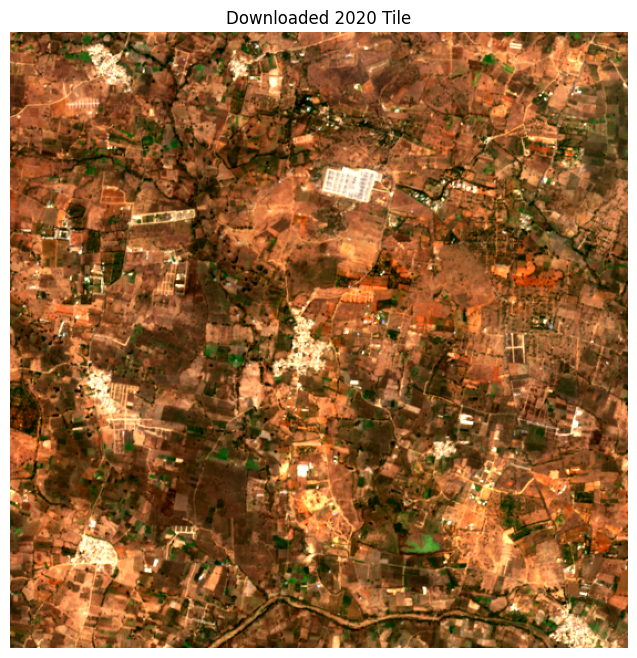

In [ ]:
with rasterio.open(sample_tile) as src:

    data = src.read().astype(np.float32)

rgb = np.stack([
    data[2],  # B4
    data[1],  # B3
    data[0]   # B2
], axis=-1)

rgb_min = np.percentile(rgb, 2)
rgb_max = np.percentile(rgb, 98)

rgb_display = np.clip(
    (rgb - rgb_min) /
    (rgb_max - rgb_min + 1e-8),
    0,
    1
)

plt.figure(figsize=(8, 8))

plt.imshow(rgb_display)

plt.title("Downloaded 2020 Tile")

plt.axis("off")

plt.show()

In [ ]:
valid_2020 = info_2020[
    (info_2020["size_MB"] >= 1) &
    (info_2020["bands"] == 9)
]["filename"].tolist()

valid_2025 = info_2025[
    (info_2025["size_MB"] >= 1) &
    (info_2025["bands"] == 9)
]["filename"].tolist()

print("Valid 2020 tiles:", len(valid_2020))
print("Valid 2025 tiles:", len(valid_2025))

Valid 2020 tiles: 63
Valid 2025 tiles: 63


In [ ]:
common_tiles = sorted(
    set(valid_2020).intersection(
        set(valid_2025)
    )
)

print(
    "Tiles available in both 2020 and 2025:",
    len(common_tiles)
)

print(common_tiles)

Tiles available in both 2020 and 2025: 63
['tile_000.tif', 'tile_001.tif', 'tile_002.tif', 'tile_003.tif', 'tile_004.tif', 'tile_005.tif', 'tile_006.tif', 'tile_007.tif', 'tile_008.tif', 'tile_009.tif', 'tile_010.tif', 'tile_011.tif', 'tile_012.tif', 'tile_013.tif', 'tile_014.tif', 'tile_015.tif', 'tile_016.tif', 'tile_017.tif', 'tile_018.tif', 'tile_019.tif', 'tile_020.tif', 'tile_021.tif', 'tile_022.tif', 'tile_023.tif', 'tile_024.tif', 'tile_025.tif', 'tile_026.tif', 'tile_027.tif', 'tile_028.tif', 'tile_029.tif', 'tile_030.tif', 'tile_031.tif', 'tile_032.tif', 'tile_033.tif', 'tile_034.tif', 'tile_035.tif', 'tile_036.tif', 'tile_037.tif', 'tile_038.tif', 'tile_039.tif', 'tile_040.tif', 'tile_041.tif', 'tile_042.tif', 'tile_043.tif', 'tile_044.tif', 'tile_045.tif', 'tile_046.tif', 'tile_047.tif', 'tile_048.tif', 'tile_049.tif', 'tile_050.tif', 'tile_051.tif', 'tile_052.tif', 'tile_053.tif', 'tile_054.tif', 'tile_055.tif', 'tile_056.tif', 'tile_057.tif', 'tile_058.tif', 'tile_059.tif

In [ ]:
tile_array = np.array(common_tiles)

train_tiles, temp_tiles = train_test_split(
    tile_array,
    test_size=0.30,
    random_state=42
)

val_tiles, test_tiles = train_test_split(
    temp_tiles,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_tiles))
print("Validation:", len(val_tiles))
print("Test:", len(test_tiles))

Train: 44
Validation: 9
Test: 10


In [ ]:
splits_dir = os.path.join(
    dataset_dir,
    "metadata",
    "splits"
)

os.makedirs(
    splits_dir,
    exist_ok=True
)

with open(
    os.path.join(splits_dir, "train.txt"),
    "w"
) as f:

    for tile in train_tiles:
        f.write(tile + "\n")


with open(
    os.path.join(splits_dir, "val.txt"),
    "w"
) as f:

    for tile in val_tiles:
        f.write(tile + "\n")


with open(
    os.path.join(splits_dir, "test.txt"),
    "w"
) as f:

    for tile in test_tiles:
        f.write(tile + "\n")


print("Train/validation/test split files saved.")

Train/validation/test split files saved.


In [ ]:
metadata_rows = []

for tile in common_tiles:

    info_row = info_2020[
        info_2020["filename"] == tile
    ].iloc[0]

    if tile in train_tiles:
        split = "train"

    elif tile in val_tiles:
        split = "validation"

    else:
        split = "test"

    metadata_rows.append({

        "tile_id": tile.replace(".tif", ""),

        "filename_2020": tile,

        "filename_2025": tile,

        "width": info_row["width"],

        "height": info_row["height"],

        "bands": info_row["bands"],

        "split": split

    })

metadata_df = pd.DataFrame(
    metadata_rows
)

metadata_df.to_csv(
    os.path.join(
        dataset_dir,
        "metadata",
        "metadata.csv"
    ),
    index=False
)

display(metadata_df)

,tile_id,filename_2020,filename_2025,width,height,bands,split
0,tile_000,tile_000.tif,tile_000.tif,558,557,9,validation
1,tile_001,tile_001.tif,tile_001.tif,558,558,9,train
2,tile_002,tile_002.tif,tile_002.tif,558,557,9,train
3,tile_003,tile_003.tif,tile_003.tif,558,558,9,test
4,tile_004,tile_004.tif,tile_004.tif,558,558,9,train
...,...,...,...,...,...,...,...
58,tile_058,tile_058.tif,tile_058.tif,557,557,9,train
59,tile_059,tile_059.tif,tile_059.tif,557,558,9,train
60,tile_060,tile_060.tif,tile_060.tif,557,558,9,validation
61,tile_061,tile_061.tif,tile_061.tif,557,557,9,test


In [ ]:
feature_df = pd.DataFrame({

    "band_number": range(1, 10),

    "feature": feature_bands

})

feature_df.to_csv(
    os.path.join(
        dataset_dir,
        "metadata",
        "feature_bands.csv"
    ),
    index=False
)

display(feature_df)

,band_number,feature
0,1,B2
1,2,B3
2,3,B4
3,4,B8
4,5,B11
5,6,B12
6,7,NDVI
7,8,NDWI
8,9,NDBI


In [ ]:
summary = {

    "2020 downloaded tiles":
        len(tiles_2020),

    "2025 downloaded tiles":
        len(tiles_2025),

    "Common usable tile pairs":
        len(common_tiles),

    "Training tiles":
        len(train_tiles),

    "Validation tiles":
        len(val_tiles),

    "Testing tiles":
        len(test_tiles),

    "Features":
        len(feature_bands)

}

summary_df = pd.DataFrame(
    summary.items(),
    columns=[
        "Property",
        "Value"
    ]
)

display(summary_df)

,Property,Value
0,2020 downloaded tiles,70
1,2025 downloaded tiles,70
2,Common usable tile pairs,63
3,Training tiles,44
4,Validation tiles,9
5,Testing tiles,10
6,Features,9


In [ ]:
zip_base = "/content/sentinel2_lulc_dataset"

shutil.make_archive(
    zip_base,
    "zip",
    dataset_dir
)

zip_path = zip_base + ".zip"

print("Dataset ZIP created.")
print(zip_path)

print(
    "ZIP size:",
    round(
        os.path.getsize(zip_path) /
        (1024 ** 2),
        2
    ),
    "MB"
)

Dataset ZIP created.
/content/sentinel2_lulc_dataset.zip
ZIP size: 946.41 MB


In [ ]:
with zipfile.ZipFile(
    zip_path,
    "r"
) as z:

    files = z.namelist()

print(
    "Files inside ZIP:",
    len(files)
)

for file in files[:20]:
    print(file)

Files inside ZIP: 149
2020/
2025/
metadata/
2020/tile_020.tif
2020/tile_063.tif
2020/tile_048.tif
2020/tile_047.tif
2020/tile_030.tif
2020/tile_026.tif
2020/tile_034.tif
2020/tile_008.tif
2020/tile_006.tif
2020/tile_043.tif
2020/tile_053.tif
2020/tile_050.tif
2020/tile_022.tif
2020/tile_062.tif
2020/tile_052.tif
2020/tile_066.tif
2020/tile_036.tif


In [ ]:
worldcover = ee.Image(
    "ESA/WorldCover/v100/2020"
).select("Map")

worldcover = worldcover.clip(study_area)

print("WorldCover 2020 loaded.")

WorldCover 2020 loaded.


In [ ]:

lulc_2020 = worldcover.remap(
    [
        10, 20, 30, 40, 95, 100,  # Vegetation
        50,                         # Built-up
        60,                         # Bare Land
        80, 90                      # Water
    ],
    [
        1, 1, 1, 1, 1, 1,          # Vegetation
        2,                          # Built-up
        3,                          # Bare Land
        0, 0                        # Water
    ],
    99
).rename("LULC")

print("LULC labels remapped.")

LULC labels remapped.


In [ ]:
Map = geemap.Map()

Map.centerObject(
    study_area,
    10
)

Map.addLayer(
    lulc_2020,
    {
        "min": 0,
        "max": 3,
        "palette": [
            "0000FF",  # Water
            "00FF00",  # Vegetation
            "FF0000",  # Built-up
            "FFFF00"   # Bare Land
        ]
    },
    "LULC 2020"
)

Map

Map(center=[17.425070303037895, 78.42499999999899], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# ==========================================
# CREATE CLEAN LABEL DIRECTORY
# ==========================================

# Existing dataset created earlier
dataset_dir = "/content/lulc_dataset"

# Clean dataset directory
clean_dataset_dir = "/content/sentinel2_lulc_dataset_clean"

# Create required directories
os.makedirs(
    os.path.join(clean_dataset_dir, "2020"),
    exist_ok=True
)

os.makedirs(
    os.path.join(clean_dataset_dir, "2025"),
    exist_ok=True
)

os.makedirs(
    os.path.join(clean_dataset_dir, "labels_2020"),
    exist_ok=True
)

os.makedirs(
    os.path.join(clean_dataset_dir, "metadata", "splits"),
    exist_ok=True
)

print("Clean dataset directory created:")
print(clean_dataset_dir)

Clean dataset directory created:
/content/sentinel2_lulc_dataset_clean


In [ ]:
# ==========================================
# EXPORT MATCHING 2020 LULC LABEL TILES
# ==========================================

label_dir = os.path.join(
    clean_dataset_dir,
    "labels_2020"
)

label_number = 0

x = xmin

while x < xmax:

    x2 = min(x + tile_size, xmax)

    y = ymin

    while y < ymax:

        y2 = min(y + tile_size, ymax)

        tile_geometry = ee.Geometry.Rectangle([
            x,
            y,
            x2,
            y2
        ])

        tile_id = f"tile_{label_number:03d}"

        # Export only usable paired tiles
        if tile_id + ".tif" in common_tiles:

            label_tile = lulc_2020.clip(
                tile_geometry
            )

            output_path = os.path.join(
                label_dir,
                tile_id + ".tif"
            )

            print(
                f"Exporting label: {tile_id}"
            )

            try:

                geemap.ee_export_image(
                    label_tile,
                    filename=output_path,
                    scale=10,
                    region=tile_geometry,
                    file_per_band=False
                )

                if os.path.exists(output_path):

                    size_mb = (
                        os.path.getsize(output_path)
                        / (1024 ** 2)
                    )

                    print(
                        f"✓ Saved: {size_mb:.2f} MB"
                    )

                else:
                    print("✗ Export failed.")

            except Exception as e:

                print(
                    f"✗ Error: {e}"
                )

        label_number += 1
        y += tile_size

    x += tile_size

print()
print("================================")
print("2020 LULC label export complete")
print("================================")

Exporting label: tile_000
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_000.tif
✓ Saved: 0.01 MB
Exporting label: tile_001
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_001.tif
✓ Saved: 0.02 MB
Exporting label: tile_002
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_002.tif
✓ Saved: 0.01 MB
Exporting label: tile_003
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_003.tif
✓ Saved: 0.02 MB
Exporting label: tile_004
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_004.tif
✓ Saved: 0.02 MB
Exporting label: tile_005
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_005.tif
✓ Saved: 0.02 MB
Exporting label: tile_006
Generating URL

In [ ]:
label_files = sorted(
    glob.glob(
        os.path.join(
            clean_dataset_dir,
            "labels_2020",
            "*.tif"
        )
    )
)

print("Number of label tiles:", len(label_files))

for f in label_files[:10]:
    print(os.path.basename(f))

Number of label tiles: 63
tile_000.tif
tile_001.tif
tile_002.tif
tile_003.tif
tile_004.tif
tile_005.tif
tile_006.tif
tile_007.tif
tile_008.tif
tile_009.tif


In [ ]:
label_dir = os.path.join(
    clean_dataset_dir,
    "labels_2020"
)

os.makedirs(
    label_dir,
    exist_ok=True
)

print("Label directory created:")
print(label_dir)

Label directory created:
/content/sentinel2_lulc_dataset_clean/labels_2020


In [ ]:
# ==========================================
# EXPORT 2020 LULC LABEL TILES
# ==========================================

label_number = 0

x = xmin

while x < xmax:

    x2 = min(x + tile_size, xmax)

    y = ymin

    while y < ymax:

        y2 = min(y + tile_size, ymax)

        tile_geometry = ee.Geometry.Rectangle([
            x, y, x2, y2
        ])

        tile_id = f"tile_{label_number:03d}"

        # Export only tiles that have valid 2020/2025 pairs
        if tile_id + ".tif" in common_tiles:

            label_tile = lulc_2020.clip(tile_geometry)

            output_path = os.path.join(
                label_dir,
                tile_id + ".tif"
            )

            print(f"Exporting label: {tile_id}")

            try:

                geemap.ee_export_image(
                    label_tile,
                    filename=output_path,
                    scale=10,
                    region=tile_geometry,
                    file_per_band=False
                )

                if os.path.exists(output_path):

                    size_mb = (
                        os.path.getsize(output_path)
                        / (1024 ** 2)
                    )

                    print(
                        f"✓ Saved: {size_mb:.2f} MB"
                    )

                else:
                    print("✗ Export failed.")

            except Exception as e:

                print(f"✗ Error: {e}")

        label_number += 1
        y += tile_size

    x += tile_size


print("\n================================")
print("2020 LULC label export complete.")
print("================================")

Exporting label: tile_000
Generating URL ...


Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_000.tif
✓ Saved: 0.01 MB
Exporting label: tile_001
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_001.tif
✓ Saved: 0.02 MB
Exporting label: tile_002
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_002.tif
✓ Saved: 0.01 MB
Exporting label: tile_003
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_003.tif
✓ Saved: 0.02 MB
Exporting label: tile_004
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_004.tif
✓ Saved: 0.02 MB
Exporting label: tile_005
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_lulc_dataset_clean/labels_2020/tile_005.tif
✓ Saved: 0.02 MB
Exporting label: tile_006
Generating URL ...
Please wait ...
Data downloaded to /cont

In [ ]:
# ==========================================
# CHECK 2020 LULC LABEL TILES
# ==========================================

label_files = sorted(
    glob.glob(
        os.path.join(
            clean_dataset_dir,
            "labels_2020",
            "*.tif"
        )
    )
)

print("Number of label tiles:", len(label_files))

print("\nFirst 10 label tiles:")
for f in label_files[:10]:
    print(os.path.basename(f))

Number of label tiles: 63

First 10 label tiles:
tile_000.tif
tile_001.tif
tile_002.tif
tile_003.tif
tile_004.tif
tile_005.tif
tile_006.tif
tile_007.tif
tile_008.tif
tile_009.tif


In [ ]:
# ==========================================
# VERIFY LULC LABEL VALUES AND DIMENSIONS
# ==========================================

from collections import Counter

print("Checking label tiles...\n")

for f in label_files[:5]:

    with rasterio.open(f) as src:

        data = src.read(1)

        unique_values = np.unique(data)

        print("File:", os.path.basename(f))
        print("Dimensions:", src.width, "x", src.height)
        print("Bands:", src.count)
        print("Unique label values:", unique_values)
        print()

Checking label tiles...

File: tile_000.tif
Dimensions: 557 x 557
Bands: 1
Unique label values: [1 2 3]

File: tile_001.tif
Dimensions: 557 x 558
Bands: 1
Unique label values: [0 1 2 3]

File: tile_002.tif
Dimensions: 557 x 558
Bands: 1
Unique label values: [1 2 3]

File: tile_003.tif
Dimensions: 557 x 557
Bands: 1
Unique label values: [1 2 3]

File: tile_004.tif
Dimensions: 557 x 558
Bands: 1
Unique label values: [1 2 3]



In [ ]:
# ==========================================
# CHECK OVERALL LULC CLASS DISTRIBUTION
# ==========================================

class_counts = Counter()

for f in label_files:

    with rasterio.open(f) as src:

        data = src.read(1)

        values, counts = np.unique(
            data,
            return_counts=True
        )

        for value, count in zip(values, counts):
            class_counts[int(value)] += int(count)


print("Overall LULC class distribution:\n")

class_names = {
    0: "Water",
    1: "Vegetation",
    2: "Built-up",
    3: "Bare Land",
    99: "Ignore"
}

total_pixels = sum(class_counts.values())

for class_id in sorted(class_counts):

    count = class_counts[class_id]

    percentage = (
        count / total_pixels
    ) * 100

    print(
        f"{class_id} - "
        f"{class_names.get(class_id, 'Unknown')}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

print("\nTotal pixels:", f"{total_pixels:,}")

Overall LULC class distribution:

0 - Water: 205,644 pixels (1.05%)
1 - Vegetation: 12,018,063 pixels (61.36%)
2 - Built-up: 5,970,308 pixels (30.48%)
3 - Bare Land: 1,391,239 pixels (7.10%)

Total pixels: 19,585,254


In [ ]:
# ==========================================
# CREATE PATCH DIRECTORIES
# ==========================================

patch_size = 128

patch_dir = os.path.join(
    clean_dataset_dir,
    "patches"
)

os.makedirs(
    os.path.join(patch_dir, "2020"),
    exist_ok=True
)

os.makedirs(
    os.path.join(patch_dir, "2025"),
    exist_ok=True
)

os.makedirs(
    os.path.join(patch_dir, "labels_2020"),
    exist_ok=True
)

print("Patch directories created:")
print(patch_dir)

Patch directories created:
/content/sentinel2_lulc_dataset_clean/patches


In [ ]:
# ==========================================
# COPY ONLY VALID TILE PAIRS
# ==========================================

source_2020 = os.path.join(dataset_dir, "2020")
source_2025 = os.path.join(dataset_dir, "2025")

clean_2020 = os.path.join(clean_dataset_dir, "2020")
clean_2025 = os.path.join(clean_dataset_dir, "2025")

copied = 0

for tile_name in sorted(common_tiles):

    src_2020 = os.path.join(source_2020, tile_name)
    src_2025 = os.path.join(source_2025, tile_name)

    dst_2020 = os.path.join(clean_2020, tile_name)
    dst_2025 = os.path.join(clean_2025, tile_name)

    if os.path.exists(src_2020) and os.path.exists(src_2025):

        shutil.copy2(src_2020, dst_2020)
        shutil.copy2(src_2025, dst_2025)

        copied += 1

print("========================================")
print("CLEAN IMAGE COPY COMPLETE")
print("========================================")
print("2020/2025 tile pairs copied:", copied)

CLEAN IMAGE COPY COMPLETE
2020/2025 tile pairs copied: 63


In [ ]:
# ==========================================
# GENERATE 128 × 128 PATCHES
# ==========================================

patch_number = 0

for _, row in metadata_df.iterrows():

    tile_id = row["tile_id"]
    split = row["split"]

    file_2020 = os.path.join(
        clean_dataset_dir,
        "2020",
        row["filename_2020"]
    )

    file_2025 = os.path.join(
        clean_dataset_dir,
        "2025",
        row["filename_2025"]
    )

    file_label = os.path.join(
        clean_dataset_dir,
        "labels_2020",
        tile_id + ".tif"
    )

    with rasterio.open(file_2020) as src_2020, \
         rasterio.open(file_2025) as src_2025, \
         rasterio.open(file_label) as src_label:

        image_2020 = src_2020.read()
        image_2025 = src_2025.read()
        label = src_label.read(1)

        height = min(
            image_2020.shape[1],
            image_2025.shape[1],
            label.shape[0]
        )

        width = min(
            image_2020.shape[2],
            image_2025.shape[2],
            label.shape[1]
        )

        # Crop to common dimensions
        image_2020 = image_2020[:, :height, :width]
        image_2025 = image_2025[:, :height, :width]
        label = label[:height, :width]

        # Generate patches
        for y in range(0, height - patch_size + 1, patch_size):

            for x in range(0, width - patch_size + 1, patch_size):

                patch_2020 = image_2020[
                    :,
                    y:y + patch_size,
                    x:x + patch_size
                ]

                patch_2025 = image_2025[
                    :,
                    y:y + patch_size,
                    x:x + patch_size
                ]

                patch_label = label[
                    y:y + patch_size,
                    x:x + patch_size
                ]

                patch_id = (
                    f"{tile_id}_patch_{patch_number:05d}"
                )

                # Output filenames
                output_2020 = os.path.join(
                    patch_dir,
                    "2020",
                    patch_id + ".npy"
                )

                output_2025 = os.path.join(
                    patch_dir,
                    "2025",
                    patch_id + ".npy"
                )

                output_label = os.path.join(
                    patch_dir,
                    "labels_2020",
                    patch_id + ".npy"
                )

                # Save patches
                np.save(output_2020, patch_2020.astype(np.float32))
                np.save(output_2025, patch_2025.astype(np.float32))
                np.save(output_label, patch_label.astype(np.uint8))

                patch_number += 1

    print(
        f"✓ {tile_id} completed | "
        f"split: {split}"
    )

print("\n========================================")
print("PATCH GENERATION COMPLETE")
print("========================================")
print("Total patches:", patch_number)

✓ tile_000 completed | split: validation


✓ tile_001 completed | split: train


✓ tile_002 completed | split: train


✓ tile_003 completed | split: test


✓ tile_004 completed | split: train


...

✓ tile_057 completed | split: test


✓ tile_058 completed | split: train


✓ tile_059 completed | split: train


✓ tile_060 completed | split: validation


✓ tile_061 completed | split: test
✓ tile_062 completed | split: train

PATCH GENERATION COMPLETE
Total patches: 1008


In [ ]:
# ==========================================
# VERIFY GENERATED PATCHES
# ==========================================

patches_2020 = sorted(
    glob.glob(
        os.path.join(
            patch_dir,
            "2020",
            "*.npy"
        )
    )
)

patches_2025 = sorted(
    glob.glob(
        os.path.join(
            patch_dir,
            "2025",
            "*.npy"
        )
    )
)

patches_labels = sorted(
    glob.glob(
        os.path.join(
            patch_dir,
            "labels_2020",
            "*.npy"
        )
    )
)

print("2020 patches :", len(patches_2020))
print("2025 patches :", len(patches_2025))
print("Label patches:", len(patches_labels))

# Check first patch
sample_2020 = np.load(patches_2020[0])
sample_2025 = np.load(patches_2025[0])
sample_label = np.load(patches_labels[0])

print("\nFirst patch shapes:")
print("2020 :", sample_2020.shape)
print("2025 :", sample_2025.shape)
print("Label:", sample_label.shape)

print("\nLabel values:")
print(np.unique(sample_label))

2020 patches : 1008
2025 patches : 1008
Label patches: 1008

First patch shapes:
2020 : (9, 128, 128)
2025 : (9, 128, 128)
Label: (128, 128)

Label values:
[1 2 3]


In [ ]:
# ==========================================
# CREATE FINAL KAGGLE DATASET ZIP
# ==========================================

kaggle_zip = "/content/sentinel2_lulc_change_dataset.zip"

# Remove old ZIP if it already exists
if os.path.exists(kaggle_zip):
    os.remove(kaggle_zip)

with zipfile.ZipFile(
    kaggle_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(patch_dir):

        for file in files:

            file_path = os.path.join(root, file)

            # Keep folder structure inside ZIP
            arcname = os.path.relpath(
                file_path,
                clean_dataset_dir
            )

            zipf.write(
                file_path,
                arcname
            )

print("========================================")
print("KAGGLE DATASET ZIP CREATED")
print("========================================")

size_gb = (
    os.path.getsize(kaggle_zip)
    / (1024 ** 3)
)

print("ZIP path:", kaggle_zip)
print(f"ZIP size: {size_gb:.2f} GB")

KAGGLE DATASET ZIP CREATED
ZIP path: /content/sentinel2_lulc_change_dataset.zip
ZIP size: 0.66 GB


In [ ]:
# ==========================================
# CREATE PATCH METADATA
# ==========================================

patch_metadata = []

for _, row in metadata_df.iterrows():

    tile_id = row["tile_id"]
    split = row["split"]

    # Find all patches belonging to this tile
    tile_patches = sorted(
        glob.glob(
            os.path.join(
                patch_dir,
                "2020",
                f"{tile_id}_patch_*.npy"
            )
        )
    )

    for patch_file in tile_patches:

        patch_id = os.path.splitext(
            os.path.basename(patch_file)
        )[0]

        patch_metadata.append({
            "patch_id": patch_id,
            "parent_tile": tile_id,
            "split": split
        })

patch_metadata_df = pd.DataFrame(
    patch_metadata
)

metadata_output = os.path.join(
    clean_dataset_dir,
    "metadata",
    "patch_metadata.csv"
)

patch_metadata_df.to_csv(
    metadata_output,
    index=False
)

print("========================================")
print("PATCH METADATA CREATED")
print("========================================")
print("Total patches:", len(patch_metadata_df))
print("\nSplit distribution:")
print(
    patch_metadata_df["split"].value_counts()
)

print("\nSaved to:")
print(metadata_output)

PATCH METADATA CREATED
Total patches: 1008

Split distribution:
split
train         704
test          160
validation    144
Name: count, dtype: int64

Saved to:
/content/sentinel2_lulc_dataset_clean/metadata/patch_metadata.csv


In [ ]:
# ==========================================
# CREATE KAGGLE VERSION 2 ZIP
# ==========================================

kaggle_zip_v2 = "/content/sentinel2_lulc_change_dataset_v2.zip"

if os.path.exists(kaggle_zip_v2):
    os.remove(kaggle_zip_v2)

with zipfile.ZipFile(
    kaggle_zip_v2,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(clean_dataset_dir):

        for file in files:

            file_path = os.path.join(root, file)

            # Skip the old ZIP files
            if file.endswith(".zip"):
                continue

            arcname = os.path.relpath(
                file_path,
                clean_dataset_dir
            )

            zipf.write(
                file_path,
                arcname
            )

print("========================================")
print("KAGGLE VERSION 2 ZIP CREATED")
print("========================================")

size_gb = (
    os.path.getsize(kaggle_zip_v2)
    / (1024 ** 3)
)

print("ZIP path:", kaggle_zip_v2)
print(f"ZIP size: {size_gb:.2f} GB")

KAGGLE VERSION 2 ZIP CREATED
ZIP path: /content/sentinel2_lulc_change_dataset_v2.zip
ZIP size: 1.59 GB
